In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
CSV_PATH = None
OUTPUT_DIR = None 

In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REQUIRED_COLUMNS = [
    "timestamp",
    "machine",
    "cpu_usage",
    "gpu_wrk_util",
    "avg_mem",
    "max_mem",
    "avg_gpu_wrk_mem",
    "max_gpu_wrk_mem",
    "read",
    "write",
    "read_count",
    "write_count",
]
NUMERIC_COLUMNS = REQUIRED_COLUMNS[2:]
DEFAULT_CSV_CANDIDATES = (
    Path("live_data.csv"),
    Path("output.csv"),
    Path("..") / "output.csv",
)


def configure_plot_style() -> None:
    """Set consistent matplotlib defaults for the analysis workflow."""
    plt.rcParams.update(
        {
            "figure.figsize": (12, 6),
            "axes.titlesize": 14,
            "axes.labelsize": 11,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        }
    )


def resolve_csv_path(csv_path: str | Path | None = None) -> Path:
    """Resolve the input CSV path from an explicit value or known defaults."""
    if csv_path is not None:
        path = Path(csv_path).expanduser()
        if path.exists():
            return path
        raise FileNotFoundError(f"CSV file not found: {path}")

    for candidate in DEFAULT_CSV_CANDIDATES:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        "No CSV file found. Set CSV_PATH to a valid file path before running the notebook."
    )


def prepare_output_dir(output_dir: str | Path | None = None) -> Path | None:
    """Create the output directory when plot export is requested."""
    if output_dir is None:
        return None

    path = Path(output_dir)
    path.mkdir(parents=True, exist_ok=True)
    return path


def validate_columns(df: pd.DataFrame) -> None:
    """Ensure the dataset contains the expected server metric columns."""
    missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")


def parse_timestamp_series(series: pd.Series) -> pd.Series:
    """Parse timestamps using the expected log format and a safe fallback."""
    parsed = pd.to_datetime(series, format="%d-%m-%y %H:%M:%S", errors="coerce")
    fallback_mask = parsed.isna() & series.notna()
    if fallback_mask.any():
        parsed.loc[fallback_mask] = pd.to_datetime(
            series.loc[fallback_mask],
            format="mixed",
            errors="coerce",
            dayfirst=True,
        )
    return parsed


def load_and_preprocess_data(csv_path: str | Path) -> pd.DataFrame:
    """Load the CSV file, normalize types, and handle missing values."""
    df = pd.read_csv(csv_path, low_memory=False)
    validate_columns(df)

    df = df[REQUIRED_COLUMNS].copy()
    df["timestamp"] = parse_timestamp_series(df["timestamp"])
    df["machine"] = df["machine"].fillna("unknown").astype(str).str.strip()
    df["machine"] = df["machine"].replace("", "unknown")

    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    if df["timestamp"].isna().all():
        raise ValueError("Unable to parse any timestamp values from the dataset.")

    df = df.dropna(subset=["timestamp"]).copy()
    machine_medians = df.groupby("machine")[NUMERIC_COLUMNS].transform("median")
    df[NUMERIC_COLUMNS] = df[NUMERIC_COLUMNS].fillna(machine_medians)
    df[NUMERIC_COLUMNS] = df[NUMERIC_COLUMNS].fillna(df[NUMERIC_COLUMNS].median())
    df = df.dropna(subset=NUMERIC_COLUMNS, how="all")
    df = df.sort_values(["timestamp", "machine"]).reset_index(drop=True)

    if df.empty:
        raise ValueError("No usable rows remain after preprocessing.")

    return df


def render_figure(fig: plt.Figure, filename: str, output_dir: Path | None = None) -> None:
    """Render the figure and optionally save it to disk."""
    fig.tight_layout()
    if output_dir is not None:
        fig.savefig(output_dir / filename, dpi=150, bbox_inches="tight")

    backend_name = plt.get_backend().lower()
    if "agg" not in backend_name:
        plt.show()

    plt.close(fig)


def plot_machine_bar_metric(
    df: pd.DataFrame,
    metric: str,
    title: str,
    ylabel: str,
    color: str,
    filename: str,
    output_dir: Path | None = None,
) -> None:
    """Plot the average value of a metric for each machine."""
    summary = df.groupby("machine", as_index=False)[metric].mean().sort_values("machine")
    x = np.arange(len(summary))

    fig, ax = plt.subplots()
    ax.bar(x, summary[metric], color=color)
    ax.set_title(title)
    ax.set_xlabel("Machine")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["machine"], rotation=45, ha="right")

    render_figure(fig, filename=filename, output_dir=output_dir)


def plot_cpu_gpu_comparison(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot grouped bars comparing average CPU and GPU usage per machine."""
    summary = df.groupby("machine")[["cpu_usage", "gpu_wrk_util"]].mean().sort_index()
    x = np.arange(len(summary.index))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar(
        x - width / 2,
        summary["cpu_usage"],
        width=width,
        label="CPU Usage",
        color="#4C78A8",
    )
    ax.bar(
        x + width / 2,
        summary["gpu_wrk_util"],
        width=width,
        label="GPU Utilization",
        color="#F58518",
    )
    ax.set_title("Average CPU vs GPU Usage per Machine")
    ax.set_xlabel("Machine")
    ax.set_ylabel("Average Usage")
    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, rotation=45, ha="right")
    ax.legend()

    render_figure(fig, filename="cpu_gpu_comparison.png", output_dir=output_dir)


def plot_metric_over_time_by_machine(
    df: pd.DataFrame,
    metric: str,
    title: str,
    ylabel: str,
    filename: str,
    output_dir: Path | None = None,
) -> None:
    """Plot a time-series metric for each machine."""
    time_series = (
        df.groupby(["timestamp", "machine"], as_index=False)[metric]
        .mean()
        .sort_values(["machine", "timestamp"])
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    for machine, machine_data in time_series.groupby("machine"):
        ax.plot(machine_data["timestamp"], machine_data[metric], label=machine, linewidth=1.8)

    ax.set_title(title)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel(ylabel)
    ax.legend(title="Machine")
    fig.autofmt_xdate(rotation=45)

    render_figure(fig, filename=filename, output_dir=output_dir)


def plot_cpu_histogram(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot the CPU usage distribution."""
    fig, ax = plt.subplots()
    ax.hist(df["cpu_usage"].dropna(), bins=30, color="#4C78A8", edgecolor="white")
    ax.set_title("Histogram of CPU Usage")
    ax.set_xlabel("CPU Usage")
    ax.set_ylabel("Frequency")

    render_figure(fig, filename="cpu_usage_histogram.png", output_dir=output_dir)


def plot_cpu_boxplot_by_machine(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot a box plot of CPU usage for each machine."""
    grouped = df.groupby("machine")["cpu_usage"]
    labels = list(grouped.groups.keys())
    values = [group.dropna().values for _, group in grouped]

    fig, ax = plt.subplots(figsize=(12, 6))
    boxplot = ax.boxplot(values, patch_artist=True)
    for patch in boxplot["boxes"]:
        patch.set_facecolor("#A0CBE8")

    ax.set_title("Box Plot of CPU Usage per Machine")
    ax.set_xlabel("Machine")
    ax.set_ylabel("CPU Usage")
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha="right")

    render_figure(fig, filename="cpu_usage_boxplot.png", output_dir=output_dir)


def plot_cpu_violinplot_by_machine(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot a violin plot of CPU usage for each machine."""
    grouped = df.groupby("machine")["cpu_usage"]
    labels = list(grouped.groups.keys())
    values = [group.dropna().values for _, group in grouped]

    fig, ax = plt.subplots(figsize=(12, 6))
    violin = ax.violinplot(values, showmeans=True, showmedians=True)
    for body in violin["bodies"]:
        body.set_facecolor("#72B7B2")
        body.set_edgecolor("#2F4B4B")
        body.set_alpha(0.75)

    for key in ("cbars", "cmins", "cmaxes", "cmeans", "cmedians"):
        if key in violin:
            violin[key].set_color("#2F4B4B")

    ax.set_title("Violin Plot of CPU Usage per Machine")
    ax.set_xlabel("Machine")
    ax.set_ylabel("CPU Usage")
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha="right")

    render_figure(fig, filename="cpu_usage_violinplot.png", output_dir=output_dir)


def plot_correlation_heatmap(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot the correlation heatmap for all numeric features."""
    correlation = df[NUMERIC_COLUMNS].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title("Correlation Heatmap of Numeric Features")
    ax.set_xticks(range(len(correlation.columns)))
    ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(correlation.index)))
    ax.set_yticklabels(correlation.index)

    for row in range(len(correlation.index)):
        for column in range(len(correlation.columns)):
            value = correlation.iloc[row, column]
            text_color = "white" if abs(value) >= 0.6 else "black"
            ax.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=9,
            )

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Correlation")

    render_figure(fig, filename="correlation_heatmap.png", output_dir=output_dir)


def plot_cpu_vs_gpu_scatter(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot CPU usage against GPU utilization."""
    fig, ax = plt.subplots()
    for machine, machine_data in df.groupby("machine"):
        ax.scatter(
            machine_data["cpu_usage"],
            machine_data["gpu_wrk_util"],
            alpha=0.5,
            s=40,
            label=machine,
        )

    ax.set_title("Scatter Plot of CPU Usage vs GPU Utilization")
    ax.set_xlabel("CPU Usage")
    ax.set_ylabel("GPU Utilization")
    ax.legend(title="Machine")

    render_figure(fig, filename="cpu_vs_gpu_scatter.png", output_dir=output_dir)


def plot_resource_stack(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot stacked CPU and GPU usage aggregated over time."""
    usage = df.groupby("timestamp")[["cpu_usage", "gpu_wrk_util"]].sum().sort_index()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.stackplot(
        usage.index,
        usage["cpu_usage"],
        usage["gpu_wrk_util"],
        labels=["CPU Usage", "GPU Utilization"],
        colors=["#4C78A8", "#F58518"],
        alpha=0.85,
    )
    ax.set_title("Stack Plot of CPU and GPU Usage Over Time")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Aggregated Usage")
    ax.legend(loc="upper left")
    fig.autofmt_xdate(rotation=45)

    render_figure(fig, filename="cpu_gpu_stackplot.png", output_dir=output_dir)


def plot_read_vs_write_per_machine(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot grouped bars comparing total read and write I/O per machine."""
    disk_io = df.groupby("machine")[["read", "write"]].sum().sort_index()
    x = np.arange(len(disk_io.index))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar(x - width / 2, disk_io["read"], width=width, label="Read", color="#54A24B")
    ax.bar(x + width / 2, disk_io["write"], width=width, label="Write", color="#E45756")
    ax.set_title("Read vs Write per Machine")
    ax.set_xlabel("Machine")
    ax.set_ylabel("Total Disk I/O")
    ax.set_xticks(x)
    ax.set_xticklabels(disk_io.index, rotation=45, ha="right")
    ax.legend()

    render_figure(fig, filename="read_vs_write_per_machine.png", output_dir=output_dir)


def plot_read_write_trends_over_time(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Plot read and write disk I/O trends over time."""
    disk_io = df.groupby("timestamp")[["read", "write"]].sum().sort_index()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(disk_io.index, disk_io["read"], label="Read", linewidth=2, color="#54A24B")
    ax.plot(disk_io.index, disk_io["write"], label="Write", linewidth=2, color="#E45756")
    ax.set_title("Read and Write Trends Over Time")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Disk I/O")
    ax.legend()
    fig.autofmt_xdate(rotation=45)

    render_figure(fig, filename="read_write_trends_over_time.png", output_dir=output_dir)


def run_analysis(df: pd.DataFrame, output_dir: Path | None = None) -> None:
    """Generate the full analysis and visualization suite."""
    plot_machine_bar_metric(
        df,
        metric="cpu_usage",
        title="Average CPU Usage per Machine",
        ylabel="Average CPU Usage",
        color="#4C78A8",
        filename="avg_cpu_per_machine.png",
        output_dir=output_dir,
    )
    plot_machine_bar_metric(
        df,
        metric="gpu_wrk_util",
        title="Average GPU Utilization per Machine",
        ylabel="Average GPU Utilization",
        color="#F58518",
        filename="avg_gpu_per_machine.png",
        output_dir=output_dir,
    )
    plot_cpu_gpu_comparison(df, output_dir=output_dir)
    plot_metric_over_time_by_machine(
        df,
        metric="cpu_usage",
        title="CPU Usage Over Time by Machine",
        ylabel="CPU Usage",
        filename="cpu_usage_over_time.png",
        output_dir=output_dir,
    )
    plot_metric_over_time_by_machine(
        df,
        metric="gpu_wrk_util",
        title="GPU Utilization Over Time by Machine",
        ylabel="GPU Utilization",
        filename="gpu_utilization_over_time.png",
        output_dir=output_dir,
    )
    plot_cpu_histogram(df, output_dir=output_dir)
    plot_cpu_boxplot_by_machine(df, output_dir=output_dir)
    plot_cpu_violinplot_by_machine(df, output_dir=output_dir)
    plot_correlation_heatmap(df, output_dir=output_dir)
    plot_cpu_vs_gpu_scatter(df, output_dir=output_dir)
    plot_resource_stack(df, output_dir=output_dir)
    plot_read_vs_write_per_machine(df, output_dir=output_dir)
    plot_read_write_trends_over_time(df, output_dir=output_dir)


def main(
    csv_path: str | Path | None = None,
    output_dir: str | Path | None = None,
) -> pd.DataFrame:
    """Load data, preprocess it, and generate all required visualizations."""
    try:
        configure_plot_style()
        resolved_csv_path = resolve_csv_path(csv_path)
        prepared_output_dir = prepare_output_dir(output_dir)
        df = load_and_preprocess_data(resolved_csv_path)
        run_analysis(df, output_dir=prepared_output_dir)
        return df
    except (FileNotFoundError, ValueError, pd.errors.EmptyDataError) as exc:
        print(f"Analysis failed: {exc}")
        raise

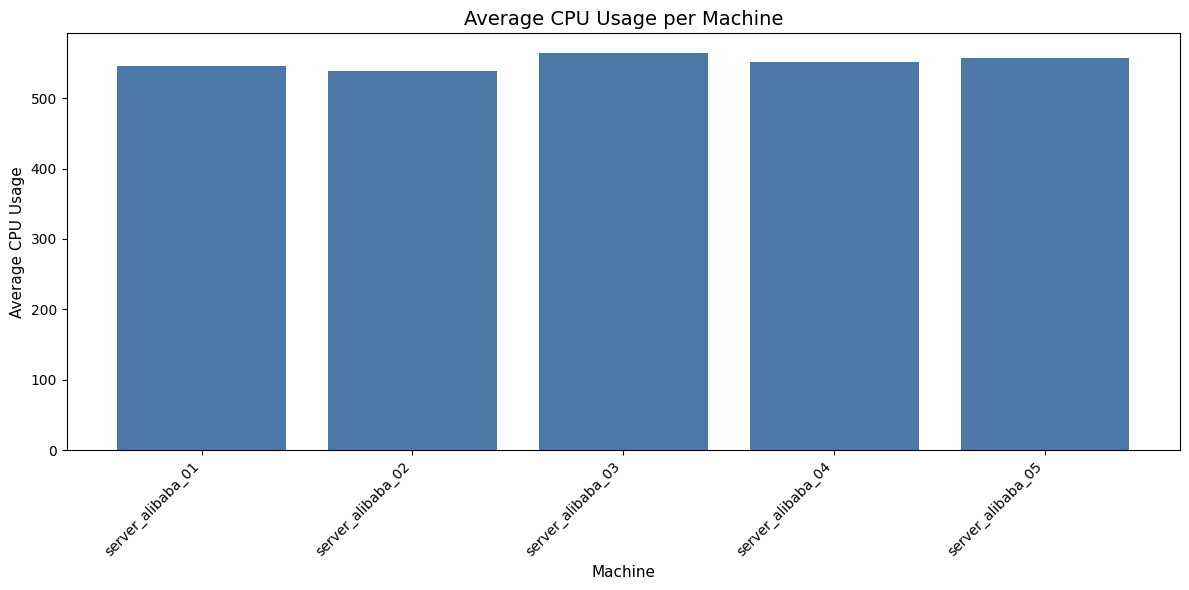

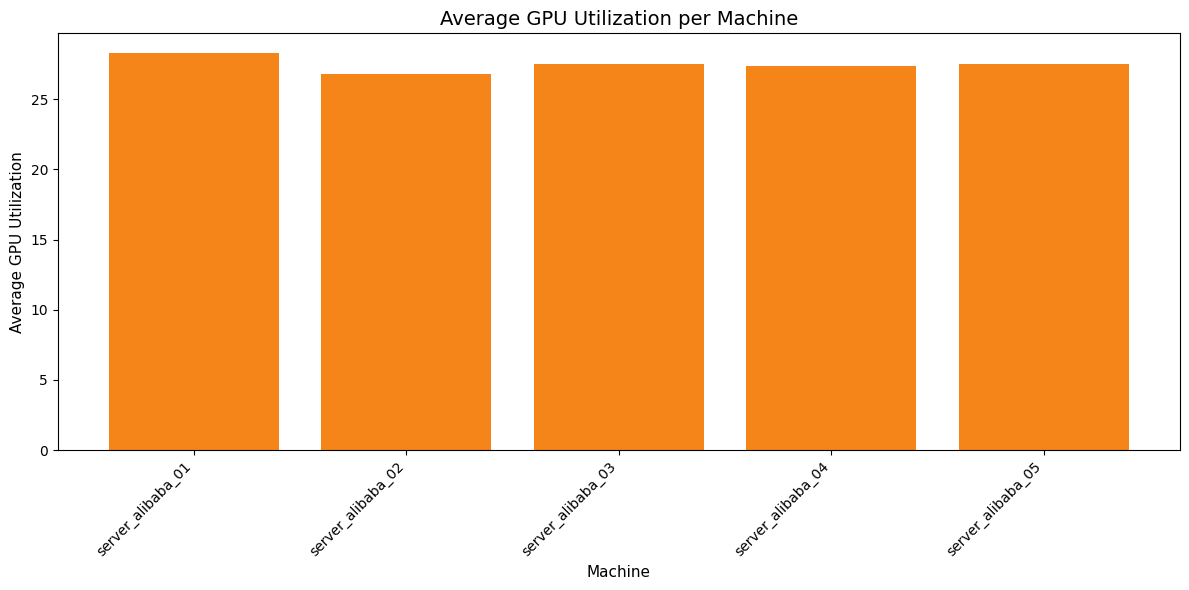

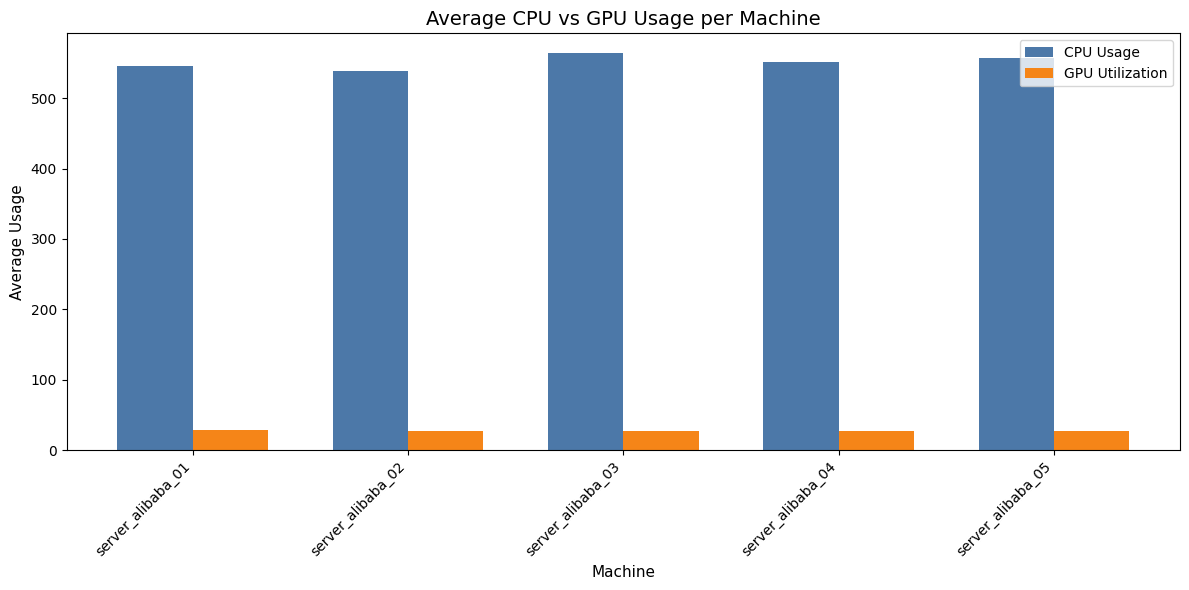

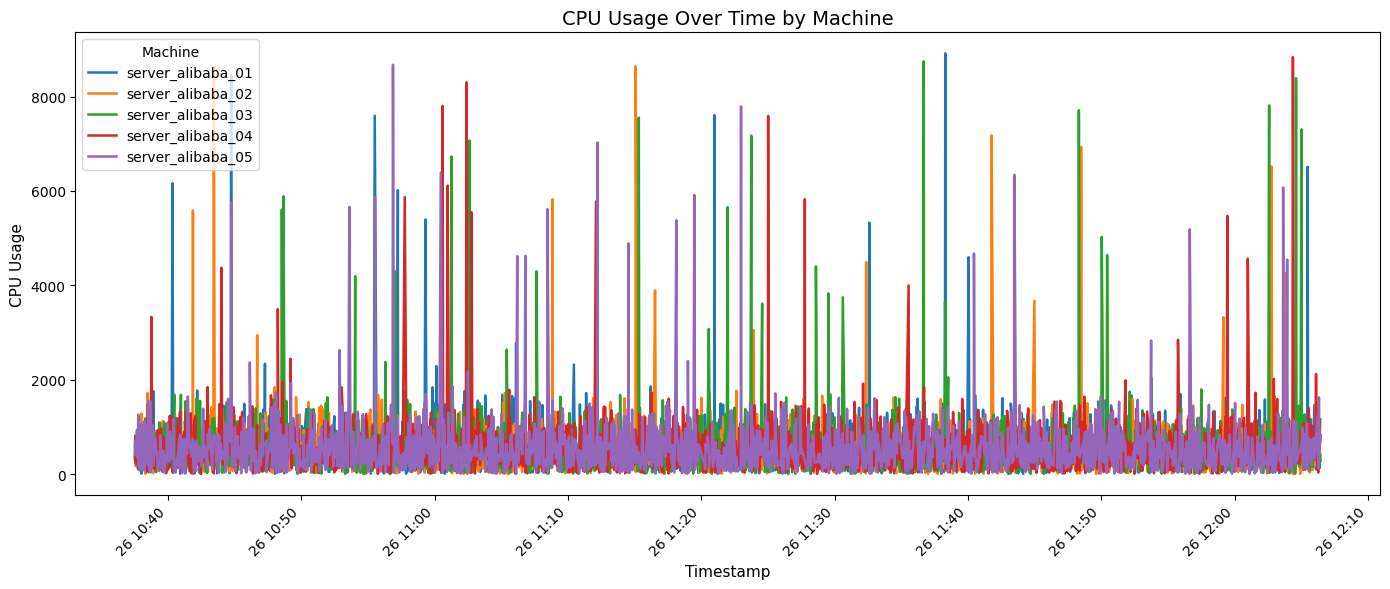

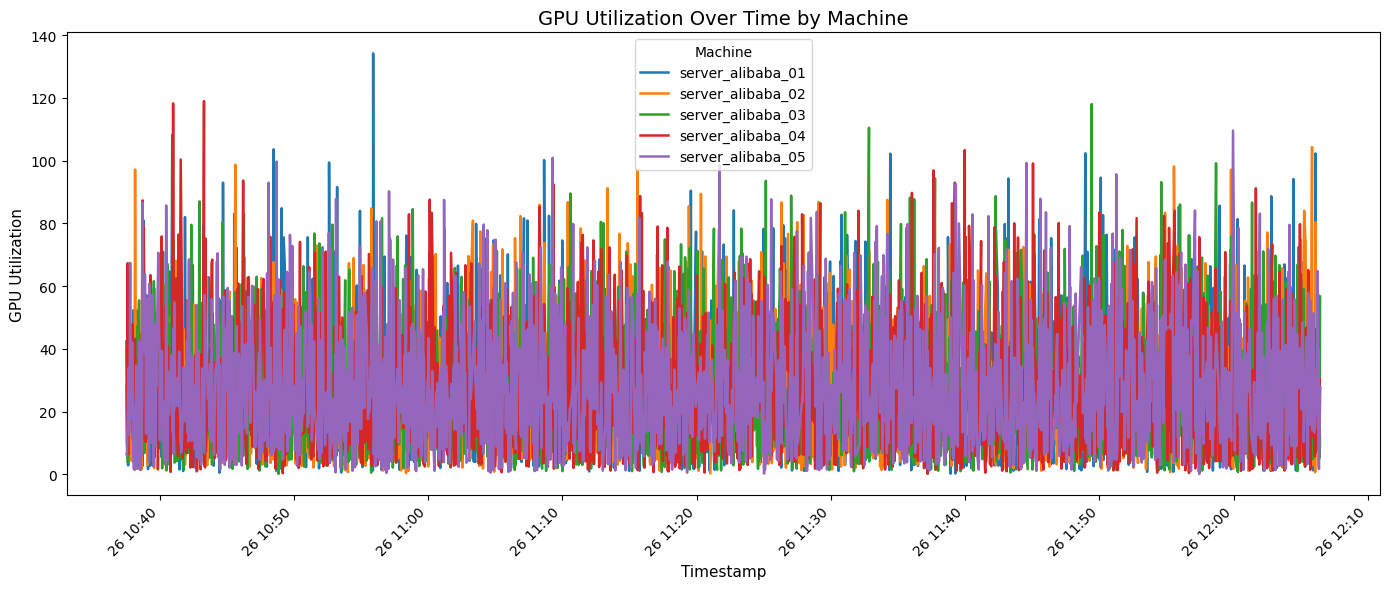

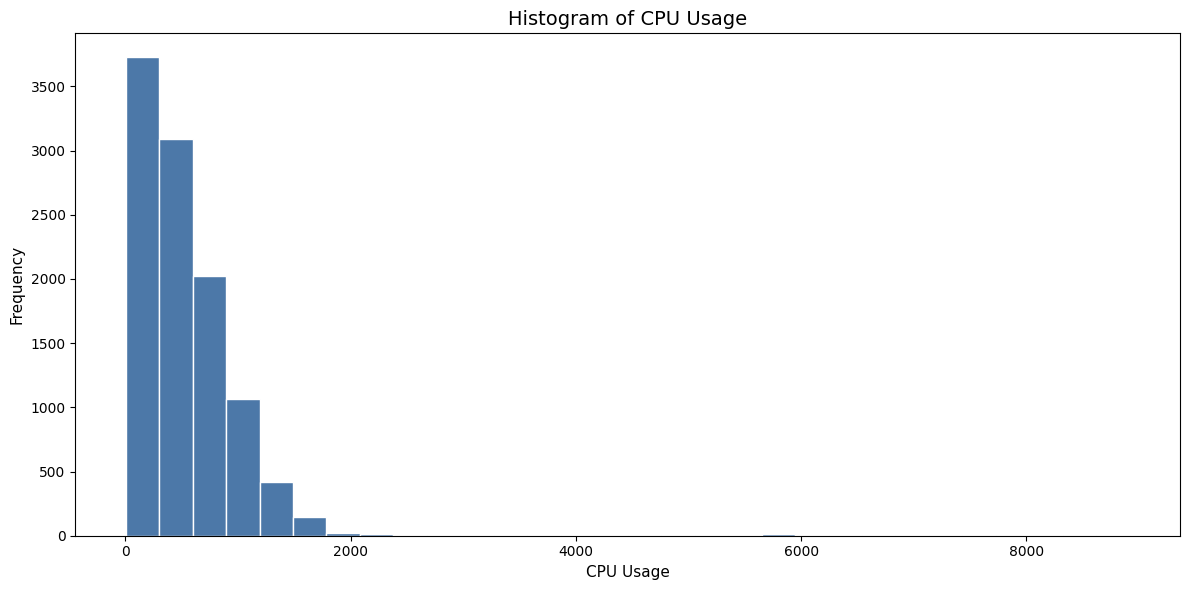

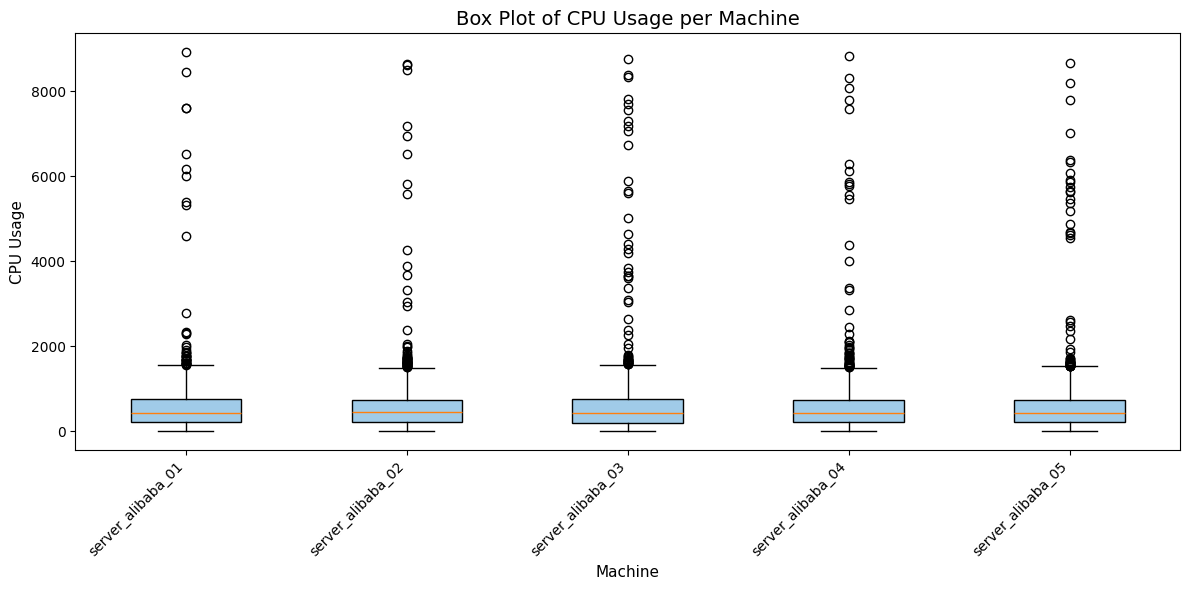

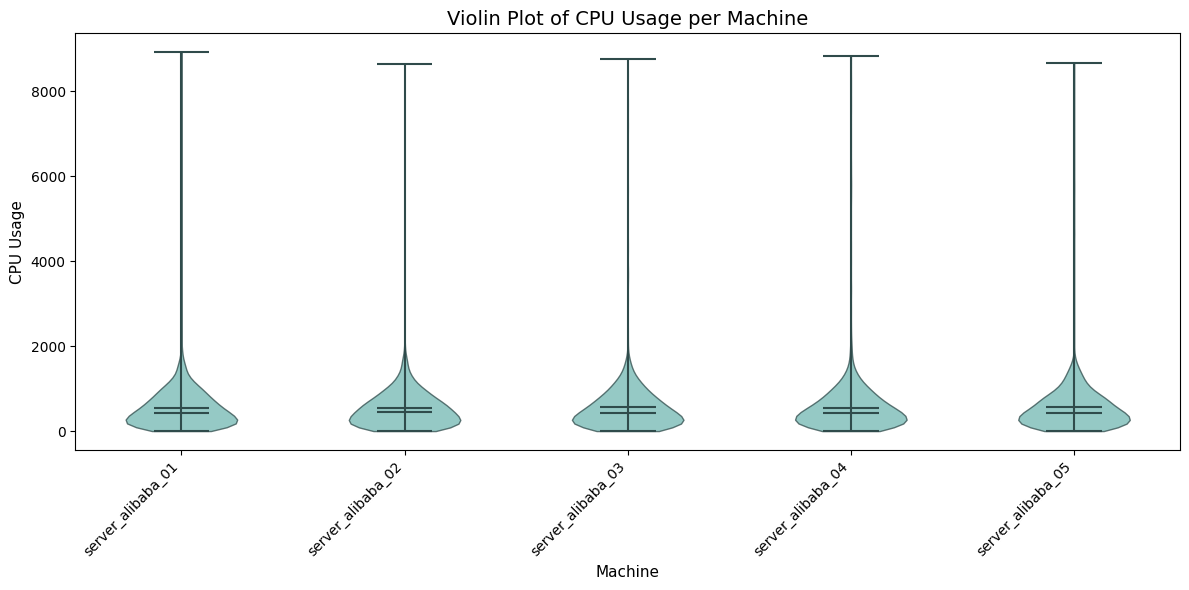

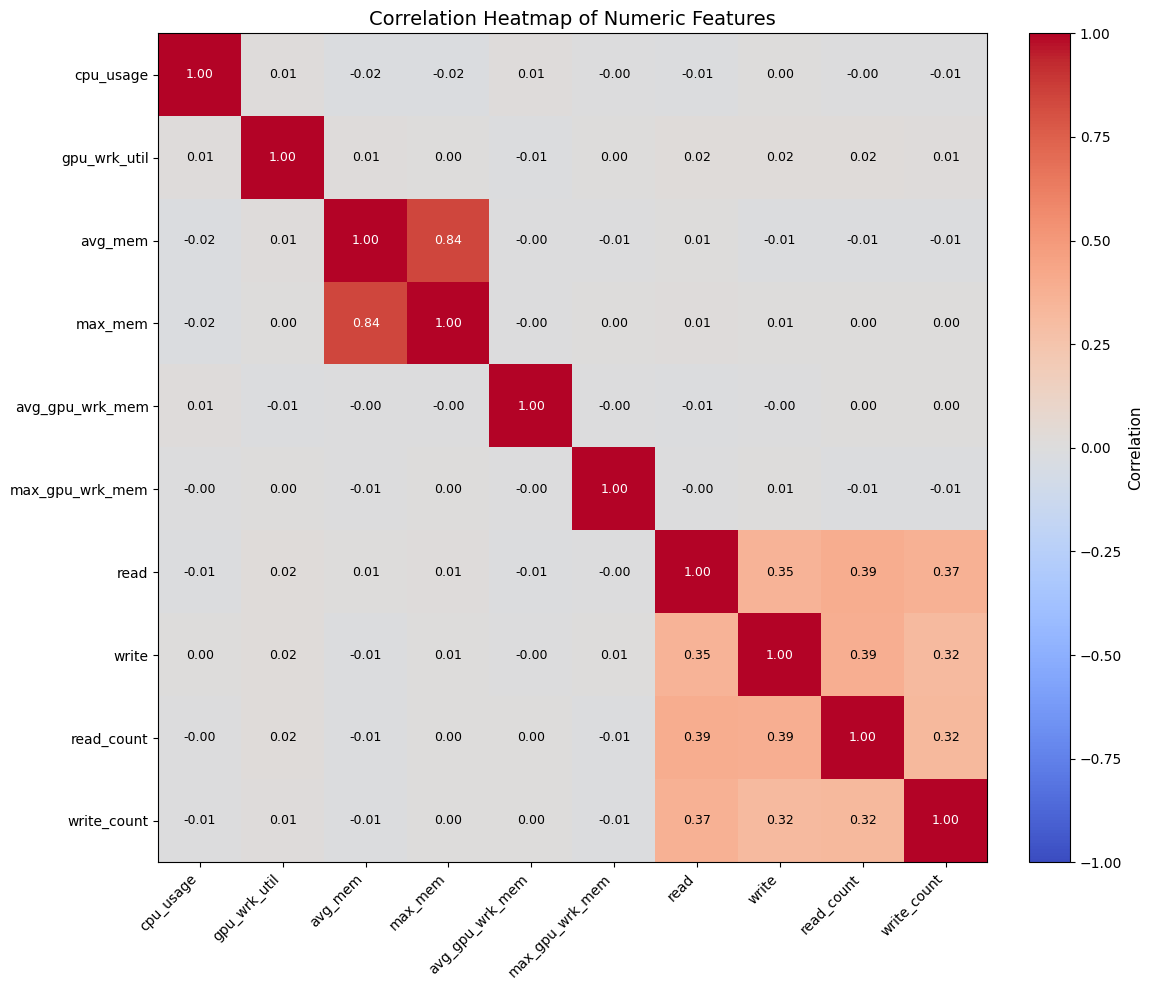

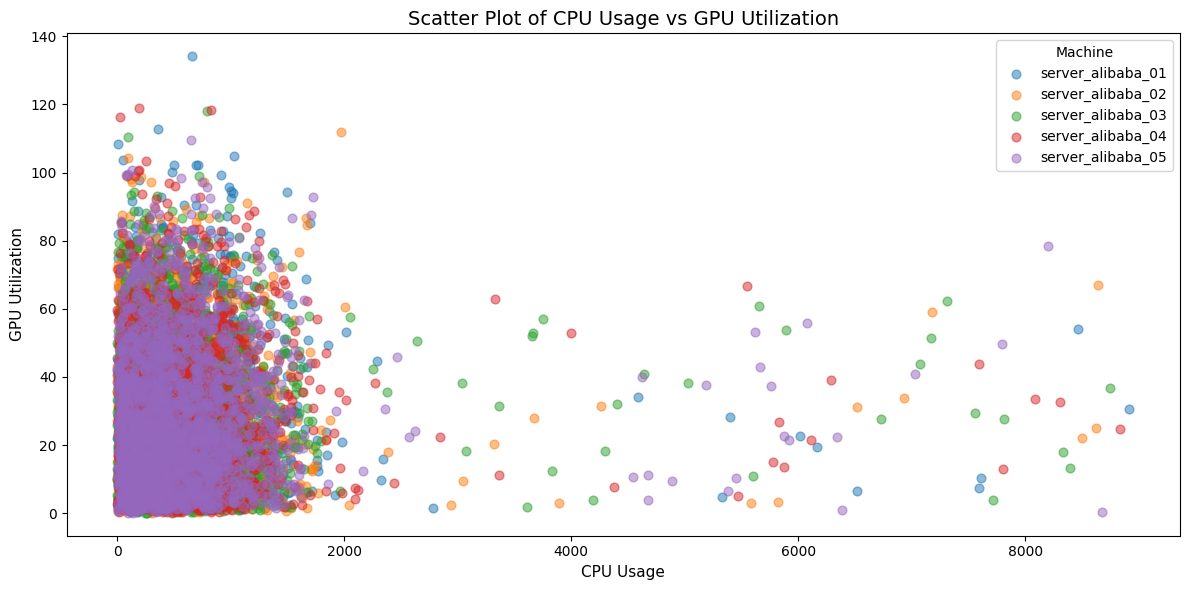

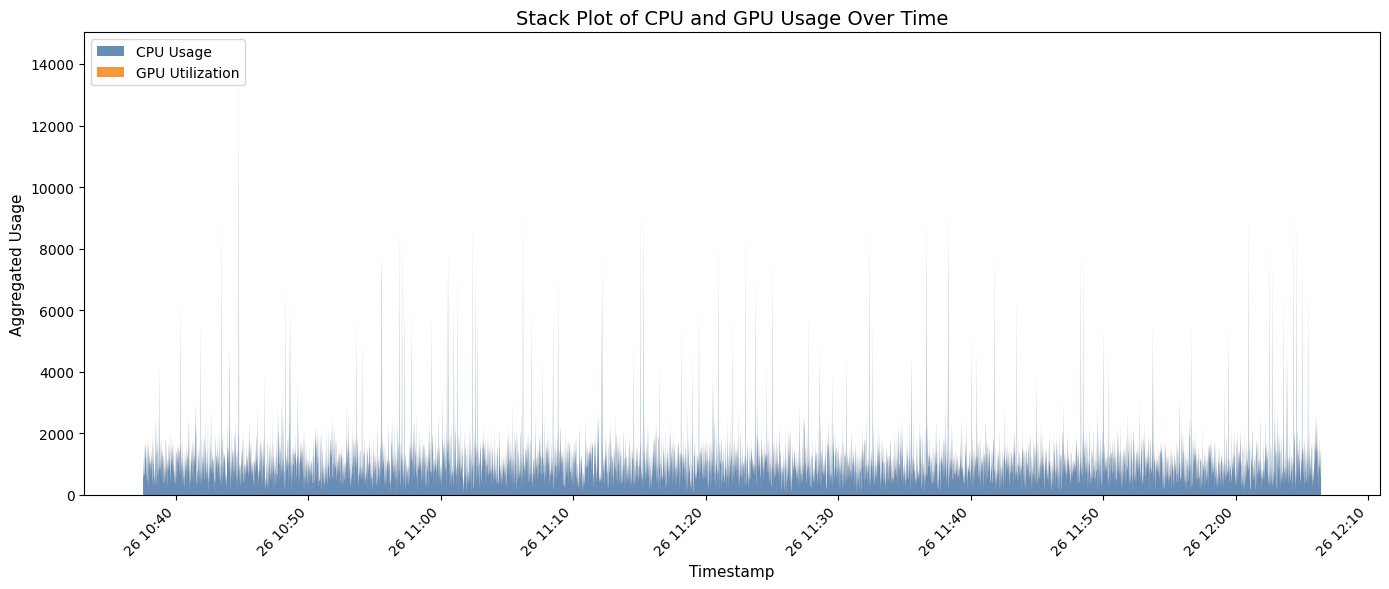

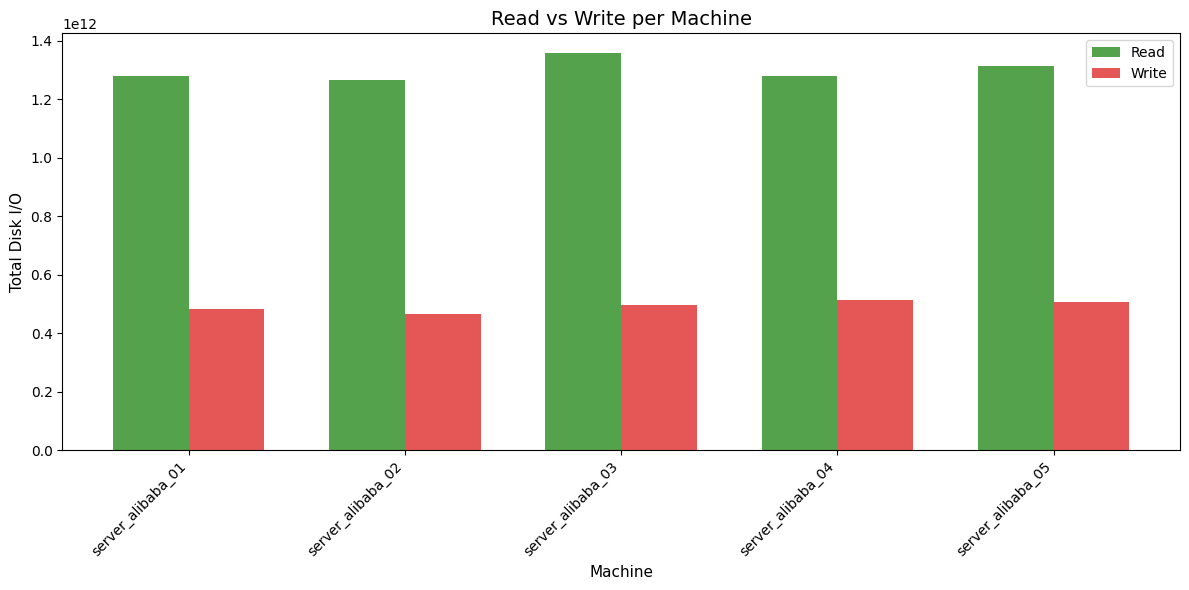

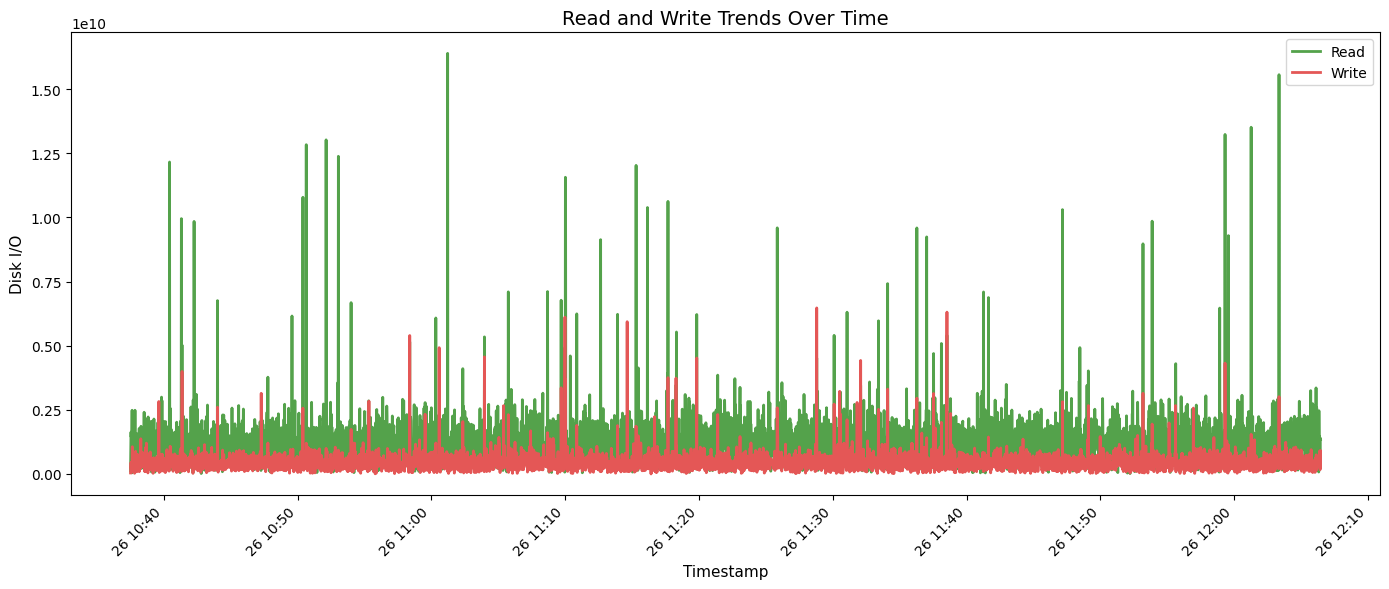

,timestamp,machine,cpu_usage,gpu_wrk_util,avg_mem,max_mem,avg_gpu_wrk_mem,max_gpu_wrk_mem,read,write,read_count,write_count
0,2026-03-26 10:37:31,server_alibaba_03,336.99,42.34,4.11,48.54,7.92,6.37,117028125,39922175,39452,63533
1,2026-03-26 10:37:32,server_alibaba_01,609.76,28.42,4.36,48.45,4.55,7.14,696010839,201113716,20002,51763
2,2026-03-26 10:37:32,server_alibaba_05,682.35,6.39,4.48,48.59,2.58,10.69,207394490,58569399,19342,66235
3,2026-03-26 10:37:33,server_alibaba_01,321.53,10.42,5.11,49.08,11.58,4.45,324563406,333536930,928,114602
4,2026-03-26 10:37:33,server_alibaba_04,285.68,39.59,4.90,49.57,16.08,3.63,1306611071,113286732,32477,24306


In [5]:
analysis_df = main(csv_path=CSV_PATH, output_dir=OUTPUT_DIR)
analysis_df.head()